# Analyze difference between current headroom and projected electric grid load

This notebook analyzes the difference between the hosting capacity calculated utilizing current ICA data and projected electricity needs in California at the census tract level. The projected load data contains the 2020 census tract data while the calculated hosting capacity data utilizes the 2025 census tract data. To match these dataset a spatial join is utilized.

In [6]:
# load libraries
import pandas as pd 
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [7]:
# load in data
projected_load = pd.read_csv('/../../capstone/electrigrid/data/projected_load/tract_scenario_comparison.csv')
tract_summary = pd.read_csv('/../../capstone/electrigrid/data/projected_load/tract_summary.csv')
sce_hostcap = gpd.read_parquet('/../../capstone/electrigrid/data/census_hosting_capacity/sce_census_map_new.parquet')
census2020 = gpd.read_file('/../../capstone/electrigrid/data/census/censustract2020/tl_2020_06_tract.shp')

# Investigate the tract summary data

In [8]:
tract_summary

,tract_id,scenario,annual_heating,peak_heating,peak_hour_heating,annual_cooling,peak_cooling,peak_hour_cooling,annual_hvac,peak_hvac,...,monthly_average_peak_exports_m03,monthly_average_peak_exports_m04,monthly_average_peak_exports_m05,monthly_average_peak_exports_m06,monthly_average_peak_exports_m07,monthly_average_peak_exports_m08,monthly_average_peak_exports_m09,monthly_average_peak_exports_m10,monthly_average_peak_exports_m11,monthly_average_peak_exports_m12
0,101050101,baseline,2355214.704,2472.808,1303,6637557.742,5576.662,4936,9.049241e+06,5590.470,...,1450.209626,1833.681377,1925.371581,1700.288787,1331.944806,1490.284293,1598.494210,1495.433939,969.630944,856.646095
1,101050102,baseline,2270635.655,2225.642,1303,3836218.190,3429.123,4936,6.142196e+06,3437.887,...,565.807475,727.653351,776.119432,698.827671,563.063739,613.761342,654.739613,603.548389,383.965592,327.047146
2,101050201,baseline,1507129.516,1523.182,1278,2876298.696,2485.575,4936,4.408875e+06,2496.747,...,158.370717,198.168605,210.526255,188.158894,150.604208,165.391451,176.539408,161.680260,100.981237,88.425195
3,101050202,baseline,2591524.081,2324.490,1272,3525976.409,3128.553,4936,6.146741e+06,3139.377,...,131.507766,164.269276,173.048946,153.991553,122.185436,135.593279,144.068135,134.811911,85.319428,74.025202
4,101050301,baseline,1062507.516,1051.209,1277,2414380.377,2237.497,4936,3.496785e+06,2242.501,...,593.455756,741.788015,773.607302,673.806714,524.436341,590.561161,640.429973,603.156111,394.726014,356.693877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18079,99003906,high,1719231.308,2243.824,1302,4207000.506,3211.390,4936,5.964284e+06,3223.346,...,383.247966,665.251178,690.472134,523.604513,194.230573,300.051751,371.564583,387.353959,185.448970,60.907252
18080,99003907,high,2398806.229,3365.878,1303,9396687.363,7891.053,4936,1.185637e+07,7913.257,...,964.646567,1595.539565,1621.402697,1147.501466,450.938790,662.854387,799.109324,868.029848,488.027393,226.569533
18081,99003908,high,1068847.430,1314.966,1303,2001602.833,1646.402,4936,3.090531e+06,1654.150,...,200.699913,367.139869,396.191972,327.814842,155.414983,216.683595,231.372468,229.347478,87.068210,28.059093
18082,99003909,high,2071215.277,2595.438,1302,7018196.062,5675.536,4936,9.137991e+06,5691.564,...,613.824155,1026.484421,1031.436301,761.895102,351.567681,471.172587,564.965073,597.766374,327.811454,141.318573


The `tract_summary` is the data for the baseline. This won't be used further in this investigation. 

## Investigate Projected Load data

In [9]:
projected_load

,tract_id,annual_heating_baseline,peak_heating_baseline,peak_hour_heating_baseline,annual_cooling_baseline,peak_cooling_baseline,peak_hour_cooling_baseline,annual_hvac_baseline,peak_hvac_baseline,peak_hour_hvac_baseline,...,pct_increase_monthly_average_peak_exports_m03,pct_increase_monthly_average_peak_exports_m04,pct_increase_monthly_average_peak_exports_m05,pct_increase_monthly_average_peak_exports_m06,pct_increase_monthly_average_peak_exports_m07,pct_increase_monthly_average_peak_exports_m08,pct_increase_monthly_average_peak_exports_m09,pct_increase_monthly_average_peak_exports_m10,pct_increase_monthly_average_peak_exports_m11,pct_increase_monthly_average_peak_exports_m12
0,101050101,2355214.704,2472.808,1303,6637557.742,5576.662,4936,9.049241e+06,5590.470,4936,...,45.124032,59.776797,62.726066,54.604039,30.887606,38.191827,39.879113,38.829196,20.096738,9.059913
1,101050102,2270635.655,2225.642,1303,3836218.190,3429.123,4936,6.142196e+06,3437.887,4936,...,62.475768,82.018839,83.649028,69.599404,30.042981,45.787471,53.004921,55.495222,27.575736,9.307794
2,101050201,1507129.516,1523.182,1278,2876298.696,2485.575,4936,4.408875e+06,2496.747,4936,...,148.455989,191.512217,194.126877,167.827969,82.771258,116.739782,137.229268,140.855593,82.776129,50.921550
3,101050202,2591524.081,2324.490,1272,3525976.409,3128.553,4936,6.146741e+06,3139.377,4936,...,195.809506,250.741196,254.917695,211.899277,85.462427,138.467900,175.994677,185.914195,103.194909,57.780798
4,101050301,1062507.516,1051.209,1277,2414380.377,2237.497,4936,3.496785e+06,2242.501,4936,...,41.179062,53.806938,54.653630,44.065369,23.851800,30.238548,32.918991,33.853377,20.012565,13.345708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9037,99003906,1567539.817,1675.641,1303,4007163.925,3009.648,4936,5.612756e+06,3021.604,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9038,99003907,1643612.243,1880.696,1303,9027033.800,7425.407,4936,1.073153e+07,7447.611,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9039,99003908,980829.110,1144.821,1303,1899860.020,1496.900,4936,2.900770e+06,1504.648,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9040,99003909,1688330.711,1672.609,1303,6871341.492,5477.952,4936,8.608252e+06,5493.980,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
projected_load.shape

(9042, 209)

There are 209 columns let's see which are the most important for us when looking at projected load data.

In [11]:
# subset for what was included in the readme
projected_load = projected_load[['tract_id', 
                                 'annual_pv_grid_baseline', 
                                 'peak_pv_grid_baseline',
                                 'annual_total_baseline',
                                 'peak_total_baseline',
                                 'annual_net_baseline',
                                 'peak_net_baseline',
                                 'annual_total_high',
                                 'annual_net_high',
                                 'pct_increase_annual_pv_grid',
                                 'p95_daily_peak_total_baseline',
                                 'p95_daily_peak_net_baseline',
                                 'p95_daily_peak_exports_baseline',
                                 'pct_increase_annual_total',
                                 'pct_increase_peak_total',
                                 'pct_increase_annual_net',
                                 'pct_increase_peak_net',
                                 'pct_increase_p95_daily_peak_total',
                                 'pct_increase_p95_daily_peak_net',
                                 'pct_increase_p95_daily_peak_exports']]

In [12]:
projected_load.head()

,tract_id,annual_pv_grid_baseline,peak_pv_grid_baseline,annual_total_baseline,peak_total_baseline,annual_net_baseline,peak_net_baseline,annual_total_high,annual_net_high,pct_increase_annual_pv_grid,p95_daily_peak_total_baseline,p95_daily_peak_net_baseline,p95_daily_peak_exports_baseline,pct_increase_annual_total,pct_increase_peak_total,pct_increase_annual_net,pct_increase_peak_net,pct_increase_p95_daily_peak_total,pct_increase_p95_daily_peak_net,pct_increase_p95_daily_peak_exports
0,101050101,2.959735e+06,2353.013571,2.418041e+07,7541.596242,2.165261e+07,6898.598399,2.569669e+07,2.013312e+07,35.885901,6785.780642,6051.076242,2103.024550,6.270672,5.083126,-7.017575,-7.658958,4.775366,-14.575055,69.942161
1,101050102,1.228744e+06,934.608793,1.478831e+07,4540.656719,1.388782e+07,4329.817895,1.572635e+07,1.324041e+07,44.122090,4047.703895,3758.999385,838.258763,6.343100,7.096314,-4.661723,-6.223291,6.411754,-9.571121,91.817151
2,101050201,3.304704e+05,252.035794,1.068719e+07,3870.539240,1.043091e+07,3814.111310,1.159768e+07,1.027810e+07,110.129063,2987.648443,2906.069323,228.615048,8.519428,4.290516,-1.464980,-2.510222,6.321410,-8.192671,216.261314
3,101050202,2.713197e+05,212.348648,1.334280e+07,4788.374193,1.313129e+07,4706.692714,1.455011e+07,1.312264e+07,133.994954,3675.509865,3600.023866,189.725772,9.048441,5.503752,-0.065857,-0.124648,8.068247,-3.404109,281.915351
4,101050301,1.202807e+06,945.061611,8.804029e+06,2933.921079,7.788774e+06,2702.590338,9.551153e+06,7.461803e+06,32.629535,2599.003287,2333.947411,850.930057,8.486157,8.183152,-4.197976,-0.988236,7.508347,-9.124383,61.359333


In [ ]:
print(projected_load['annual_total_high'].min())
print(projected_load['annual_total_high'].max())

9731.136
63425074.50381643


Assumption:  These values are for the entire census tract for all of the households.

## View hosting capacity calculations

In [14]:
sce_hostcap.head()

,GEOID,zillow_tract_hh_count,avg_DER_remain_pv_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,geometry
0,06065042516,776.0,6.02214,2.715849,7.550272,"POLYGON ((254831.161 -450428.536, 254879.224 -..."
1,06065042716,2174.0,0.00000,0.099297,4.067808,"POLYGON ((252988.226 -477491.812, 253070.244 -..."
2,06065042717,1781.0,NaN,NaN,NaN,"POLYGON ((253204.987 -475305.031, 253228.177 -..."
3,06065042902,1284.0,NaN,NaN,NaN,"POLYGON ((245709.226 -466855.471, 245710.230 -..."
4,06065042903,1417.0,NaN,NaN,NaN,"POLYGON ((244083.685 -461694.249, 244084.463 -..."


In [39]:
sce_hostcap.shape

(5104, 7)

Since the projected data contains the total data for the whole census tract we need to work at the same scale.

In [15]:
# calculate the total headroom for the whole census tract
sce_hostcap['total_DER'] = sce_hostcap['zillow_tract_hh_count'] * sce_hostcap['avg_DER_remain_load_hh']

In [16]:
print(sce_hostcap['total_DER'].min())
print(sce_hostcap['total_DER'].max())

0.0
38790.15533951731


# View 2020 Census data

The `projected_load` data does not contain geommetries. However, because the census tract numbers do not align since they're from different time periods we need the geometry from the census data.

In [17]:
# view the census data
census2020.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,029,004402,06029004402,44.02,Census Tract 44.02,G5020,S,1865739,0,+35.5917343,-119.3337642,"POLYGON ((-119.33828 35.58143, -119.33827 35.5..."
1,06,047,000802,06047000802,8.02,Census Tract 8.02,G5020,S,2321653,0,+37.3433591,-120.5854604,"POLYGON ((-120.59599 37.34121, -120.59596 37.3..."
2,06,085,501402,06085501402,5014.02,Census Tract 5014.02,G5020,S,522620,0,+37.3453341,-121.8665169,"POLYGON ((-121.87381 37.34412, -121.87361 37.3..."
3,06,005,000102,06005000102,1.02,Census Tract 1.02,G5020,S,456204155,7940832,+38.5496993,-120.2509786,"POLYGON ((-120.61016 38.41560, -120.61000 38.4..."
4,06,029,004901,06029004901,49.01,Census Tract 49.01,G5020,S,1459379,0,+35.7837173,-119.2462266,"POLYGON ((-119.25262 35.79043, -119.25259 35.7..."


In [18]:
# view the datatypes of all of the columns
census2020.dtypes

STATEFP       object
COUNTYFP      object
TRACTCE       object
GEOID         object
NAME          object
NAMELSAD      object
MTFCC         object
FUNCSTAT      object
ALAND          int64
AWATER         int64
INTPTLAT      object
INTPTLON      object
geometry    geometry
dtype: object

In [19]:
# select only the necessary columns
census2020 = census2020[['GEOID', 'geometry']]

## Utilize census data to get geometries

The `projected_load` data doesn't use the `06` prefix for the GeoID so we'll remove it from the 2020 census data so that they match.

In [21]:
# remove the unnecessary pre-crusor number from the geoid
census2020['GEOID'] = census2020['GEOID'].str.replace('06', '', regex = False)

In [22]:
# change the tract_id column to a character instead of numeric
projected_load['tract_id'] = projected_load['tract_id'].astype('string')

/tmp/ipykernel_4188593/3542139392.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  projected_load['tract_id'] = projected_load['tract_id'].astype('string')


In [ ]:
# join the census and projected load dataframe so that it contains the geometry
projected_load = pd.merge(projected_load, census2020, how = "inner", left_on = 'tract_id', right_on = 'GEOID')

In [27]:
# set the geometry 
projected_load = projected_load.set_geometry('geometry')

# set the crs
projected_load = projected_load.to_crs('EPSG:6933')

# Subtract the projected load from the existing headroom

In [29]:
# adjust the crs of sce_hostcap
sce_hostcap = sce_hostcap.to_crs('EPSG:6933')

# make sure the crs match
assert sce_hostcap.crs == projected_load.crs

In [32]:
# join the two dataframes 
join = gpd.sjoin(sce_hostcap, projected_load, how = "inner", predicate = 'intersects')


In [33]:
# view the shape of the joined dataframe
join.shape

(2619, 29)

In [34]:
# view the head of the dataframe
join.head()


,GEOID_left,zillow_tract_hh_count,avg_DER_remain_pv_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,geometry,total_DER,index_right,tract_id,annual_pv_grid_baseline,...,p95_daily_peak_net_baseline,p95_daily_peak_exports_baseline,pct_increase_annual_total,pct_increase_peak_total,pct_increase_annual_net,pct_increase_peak_net,pct_increase_p95_daily_peak_total,pct_increase_p95_daily_peak_net,pct_increase_p95_daily_peak_exports,GEOID_right
54,06101050302,798.0,1.732709,0.384243,3.536127,"POLYGON ((-11735132.050 4619893.864, -11735131...",306.626096,4,101050301,1.202807e+06,...,2333.947411,850.930057,8.486157,8.183152,-4.197976,-0.988236,7.508347,-9.124383,61.359333,101050301
54,06101050302,798.0,1.732709,0.384243,3.536127,"POLYGON ((-11735132.050 4619893.864, -11735131...",306.626096,2,101050201,3.304704e+05,...,2906.069323,228.615048,8.519428,4.290516,-1.464980,-2.510222,6.321410,-8.192671,216.261314,101050201
54,06101050302,798.0,1.732709,0.384243,3.536127,"POLYGON ((-11735132.050 4619893.864, -11735131...",306.626096,8,101050403,2.763431e+06,...,2911.952611,2010.163706,5.648276,1.493196,-14.741177,-11.594667,1.926129,-16.236256,47.664525,101050403
54,06101050302,798.0,1.732709,0.384243,3.536127,"POLYGON ((-11735132.050 4619893.864, -11735131...",306.626096,371,115040400,1.412976e+06,...,4721.663150,987.840798,6.862898,7.337590,-6.686889,-9.900358,6.665983,-13.063271,121.779676,115040400
54,06101050302,798.0,1.732709,0.384243,3.536127,"POLYGON ((-11735132.050 4619893.864, -11735131...",306.626096,6,101050401,2.686646e+06,...,4039.543544,1925.884953,5.751787,3.803518,-9.773688,-9.765319,3.485058,-15.102801,60.795007,101050401


In [35]:
# calculate the difference between the headroom and the projected load
join['diff_proj_load'] = join['total_DER'] - join['annual_net_high']

In [36]:
# save the range for mapping differences
min_diff = join['diff_proj_load'].min()
max_diff = join['diff_proj_load'].max()

# Map the differences

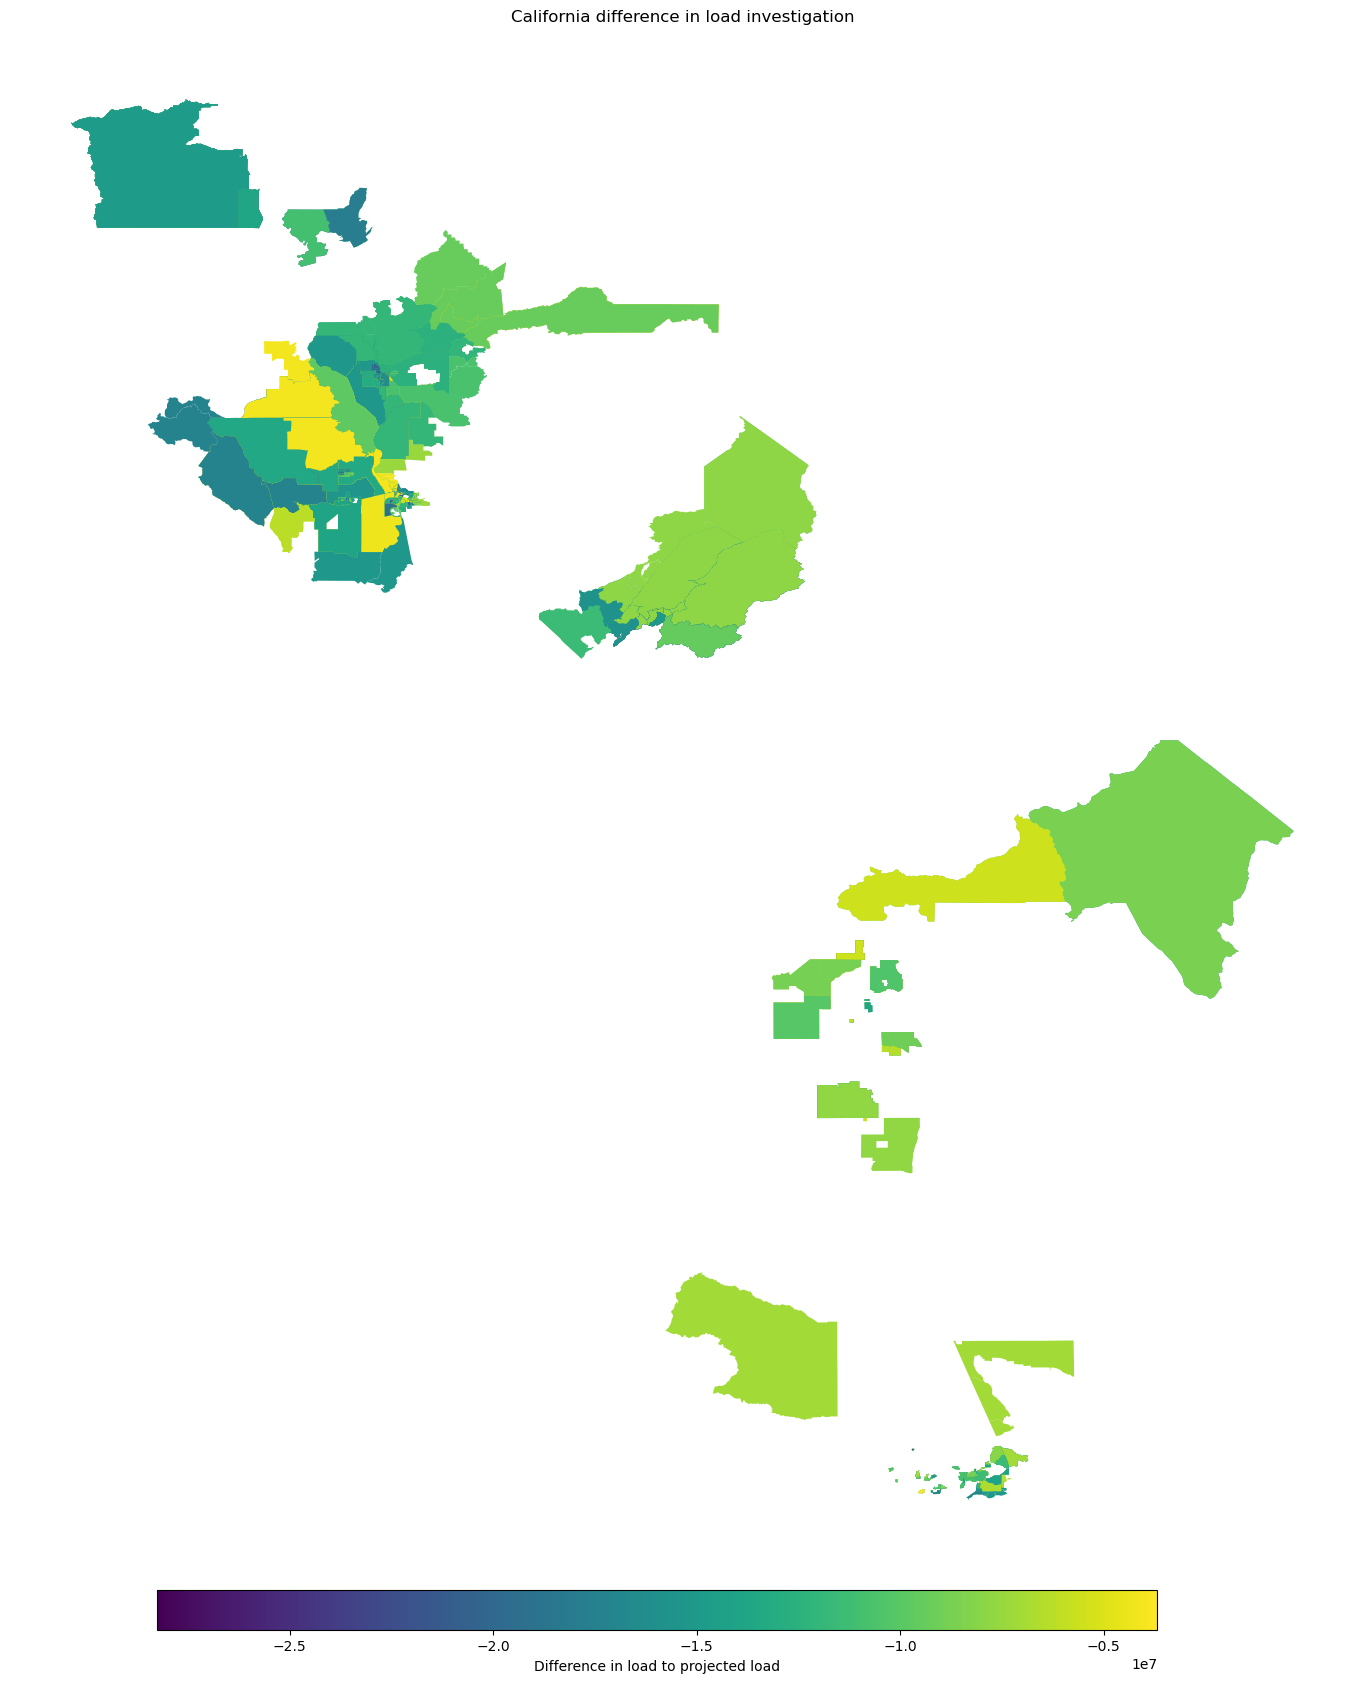

In [37]:
fig, ax = plt.subplots(figsize = (20, 20))
ax.axis('off')

join.plot('diff_proj_load',
          ax = ax)
plt.title('California difference in load investigation')

# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable( norm=plt.Normalize(vmin= min_diff, vmax=max_diff))
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Difference in load to projected load')